# Exploratory Data Analysis

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75585 entries, 0 to 75584
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pm25       75585 non-null  object
 1   pm10       75585 non-null  object
 2   no2        75585 non-null  object
 3   so2        75585 non-null  object
 4   co         75585 non-null  object
 5   o3         75585 non-null  object
 6   new_case   75585 non-null  bool  
 7   new_death  75585 non-null  bool  
dtypes: bool(2), object(6)
memory usage: 3.6+ MB
None

=== SHAPE ===
(75585, 8)

=== MISSING VALUES ===
pm25         0
pm10         0
no2          0
so2          0
co           0
o3           0
new_case     0
new_death    0
dtype: int64

=== NUMERICAL SUMMARY ===
         pm25   pm10       no2       so2        co     o3 new_case new_death
count   75585  75585     75585     75585     75585  75585    75585     75585
unique      5      5         3         3         3      3        

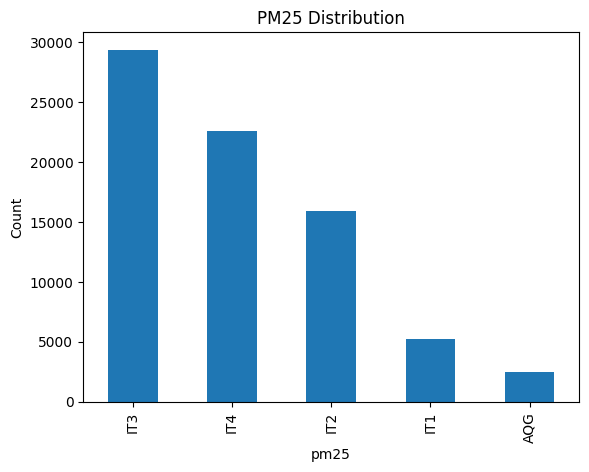


=== PM10 COUNTS ===
pm10
AQG    24084
IT4    21463
IT3    20934
IT2     9026
IT1       78
Name: count, dtype: int64


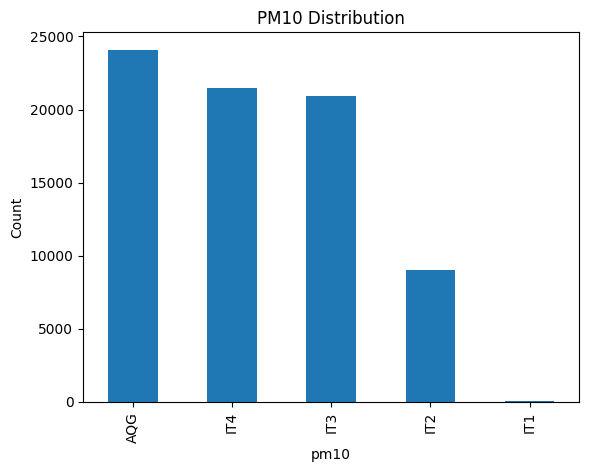


=== NO2 COUNTS ===
no2
Moderate    25876
Heavy       25095
Trace       24614
Name: count, dtype: int64


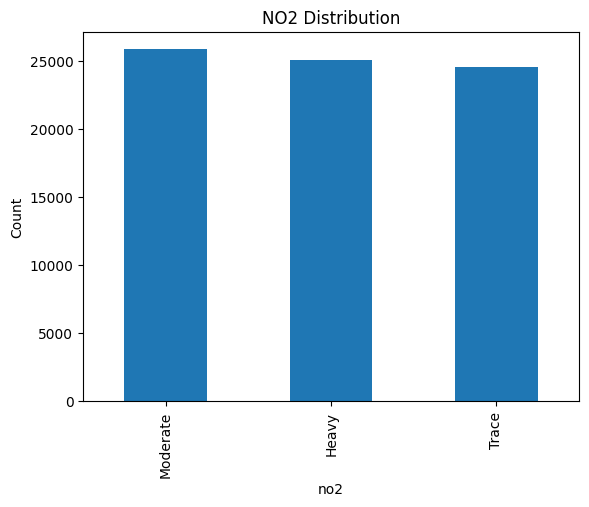


=== SO2 COUNTS ===
so2
Moderate    27357
Heavy       24115
Trace       24113
Name: count, dtype: int64


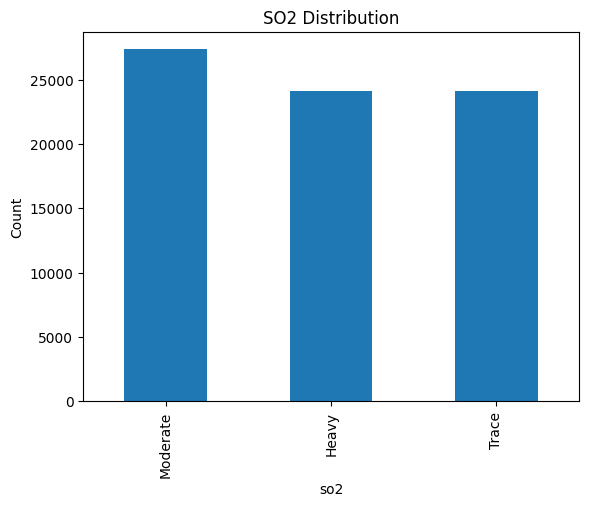


=== CO COUNTS ===
co
Moderate    33274
Heavy       25021
Trace       17290
Name: count, dtype: int64


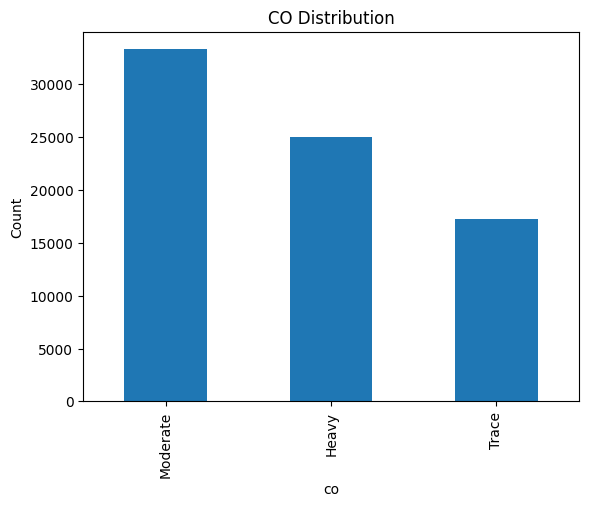


=== O3 COUNTS ===
o3
Heavy       34185
Moderate    30576
Trace       10824
Name: count, dtype: int64


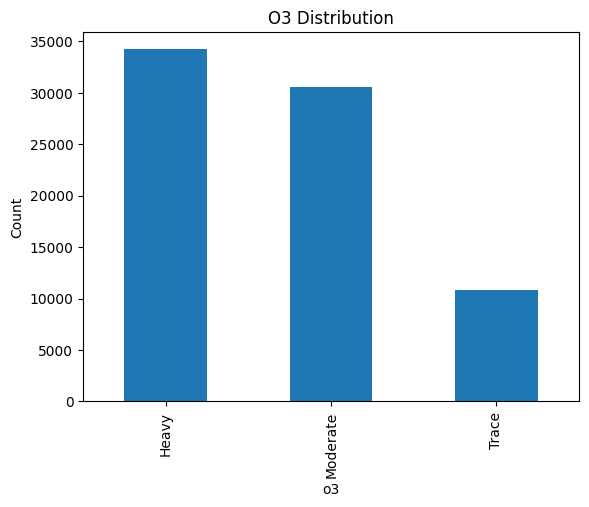


=== NEW_CASE COUNTS ===
new_case
False    60722
True     14863
Name: count, dtype: int64


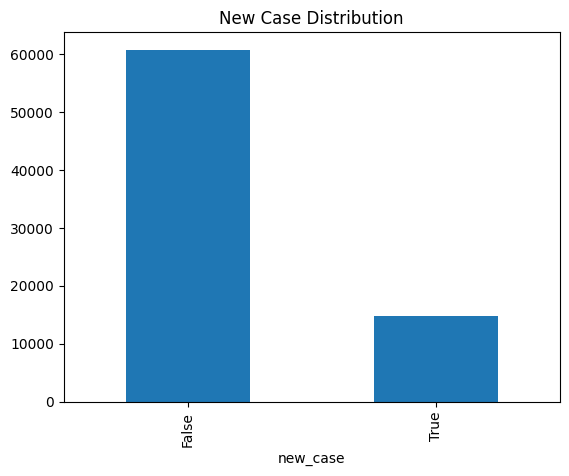


=== NEW_DEATH COUNTS ===
new_death
False    75023
True       562
Name: count, dtype: int64


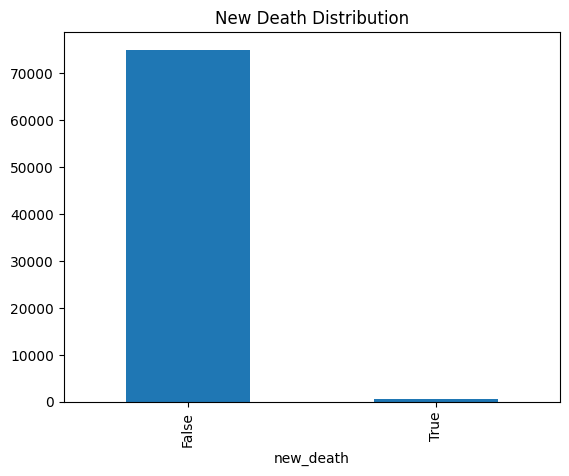


=== CLASS BALANCE ===
new_case
False    0.80336
True     0.19664
Name: proportion, dtype: float64
new_death
False    0.992565
True     0.007435
Name: proportion, dtype: float64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_data.csv")

print("=== BASIC INFO ===")
print(df.info())
print("\n=== SHAPE ===")
print(df.shape)


print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== NUMERICAL SUMMARY ===")
print(df.describe())

cols = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']

for col in cols:
    if col in df.columns:
        print(f"\n=== {col.upper()} COUNTS ===")
        print(df[col].value_counts())

        plt.figure()
        df[col].value_counts().plot(kind='bar')
        plt.title(f'{col.upper()} Distribution')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()

if 'new_case' in df.columns:
    print("\n=== NEW_CASE COUNTS ===")
    print(df['new_case'].value_counts())

    plt.figure()
    df['new_case'].value_counts().plot(kind='bar')
    plt.title('New Case Distribution')
    plt.show()

if 'new_death' in df.columns:
    print("\n=== NEW_DEATH COUNTS ===")
    print(df['new_death'].value_counts())

    plt.figure()
    df['new_death'].value_counts().plot(kind='bar')
    plt.title('New Death Distribution')
    plt.show()

print("\n=== CLASS BALANCE ===")
if 'new_case' in df.columns:
    print(df['new_case'].value_counts(normalize=True))

if 'new_death' in df.columns:
    print(df['new_death'].value_counts(normalize=True))

# New Case NB Model

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

features = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
target = 'new_case'

X = df[features].apply(lambda col: col.astype('category').cat.codes)
y = df[target].astype('category').cat.codes

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = CategoricalNB()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8368062446252563

Confusion Matrix:
 [[11510   598]
 [ 1869  1140]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90     12108
           1       0.66      0.38      0.48      3009

    accuracy                           0.84     15117
   macro avg       0.76      0.66      0.69     15117
weighted avg       0.82      0.84      0.82     15117



# New Death NB Model

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

features = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
target = 'new_death'

X = df[features].apply(lambda col: col.astype('category').cat.codes)
y = df[target].astype('category').cat.codes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = CategoricalNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9651385856982205

Confusion Matrix:
 [[14555   464]
 [   63    35]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.98     15019
           1       0.07      0.36      0.12        98

    accuracy                           0.97     15117
   macro avg       0.53      0.66      0.55     15117
weighted avg       0.99      0.97      0.98     15117

